In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.config.paths import MERGED_CSV, FIGURES_DIR

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

df = pd.read_csv(MERGED_CSV, low_memory=False)
df.shape

(27422, 49)

In [2]:
engineered_cols = ["orbit_stretch", "interaction_index", "size_energy_index", "diameter_velocity_proxy"]
df[engineered_cols].describe()

,orbit_stretch,interaction_index,size_energy_index,diameter_velocity_proxy
count,27422.000000,27422.000000,2.742200e+04,27422.000000
mean,1.282793,677.488728,2.430170e-02,0.772569
std,0.958566,6790.945145,4.627819e-01,2.870441
min,0.005000,8.333264,2.998623e-07,0.000618
25%,0.526000,28.327809,2.316978e-04,0.118295
50%,0.961000,67.563002,7.326928e-04,0.244948
75%,1.931000,226.193169,2.403931e-03,0.555036
max,7.753000,533902.829685,3.906250e+01,199.301848


In [3]:
counts_per_asteroid = df["full_name"].value_counts()
multi_approach = counts_per_asteroid[counts_per_asteroid > 1]
print(f"Asteroids with >1 close-approach event: {len(multi_approach):,} out of {len(counts_per_asteroid):,}")
print()
example_name = multi_approach.index[0]
example_rows = df[df["full_name"] == example_name][["full_name", "close_approach_date", "distance_au", "a", "e", "i", "q"]]
print(f"Example -- {example_name} has {len(example_rows)} recorded approaches:")
example_rows.sort_values("close_approach_date").head(10)

Asteroids with >1 close-approach event: 4,213 out of 20,880

Example -- (2025 PN7) has 21 recorded approaches:


,full_name,close_approach_date,distance_au,a,e,i,q
33,(2025 PN7),2015-01-16 02:34:00,0.029633,1.001,0.1079,1.98,0.893
1184,(2025 PN7),2016-01-16 00:32:00,0.039327,1.001,0.1079,1.98,0.893
2542,(2025 PN7),2016-12-29 16:32:00,0.066054,1.001,0.1079,1.98,0.893
2666,(2025 PN7),2017-02-04 20:29:00,0.066490,1.001,0.1079,1.98,0.893
3974,(2025 PN7),2017-12-06 02:25:00,0.090306,1.001,0.1079,1.98,0.893
4407,(2025 PN7),2018-03-03 15:57:00,0.088653,1.001,0.1079,1.98,0.893
16144,(2025 PN7),2023-06-02 19:25:00,0.087943,1.001,0.1079,1.98,0.893
16521,(2025 PN7),2023-08-27 12:18:00,0.090268,1.001,0.1079,1.98,0.893
18688,(2025 PN7),2024-06-30 16:58:00,0.065414,1.001,0.1079,1.98,0.893
18783,(2025 PN7),2024-07-30 05:27:00,0.065553,1.001,0.1079,1.98,0.893


In [4]:
# Notice: a, e, i, q are IDENTICAL across all rows for this asteroid (they're
# fixed orbital-shape properties) -- but distance_au varies substantially.
# This is structurally why no static-feature regression can predict distance_au well.
print("Unique (a, e, i, q) combinations for this asteroid:",
      example_rows[["a","e","i","q"]].drop_duplicates().shape[0], "(should be 1)")
print("Unique distance_au values:", example_rows["distance_au"].nunique())

Unique (a, e, i, q) combinations for this asteroid: 1 (should be 1)
Unique distance_au values: 21


In [5]:
train = df[df["is_future"] == False]
shape_features = ["a", "e", "i", "q", "ad", "diameter_km", "H"]

print("Correlation with distance_au (single-encounter distance -- a POOR target):")
for col in shape_features:
    print(f"  {col}: {train[[col,'distance_au']].corr().iloc[0,1]:.3f}")

print()
print("Correlation with moid_au (fixed orbital-shape property -- a GOOD target):")
for col in shape_features:
    print(f"  {col}: {train[[col,'moid_au']].corr().iloc[0,1]:.3f}")

Correlation with distance_au (single-encounter distance -- a POOR target):
  a: -0.055
  e: -0.102
  i: 0.204
  q: 0.064
  ad: -0.069
  diameter_km: 0.215
  H: -0.495

Correlation with moid_au (fixed orbital-shape property -- a GOOD target):
  a: 0.102
  e: -0.052
  i: 0.303
  q: 0.269
  ad: 0.058
  diameter_km: 0.155
  H: -0.430


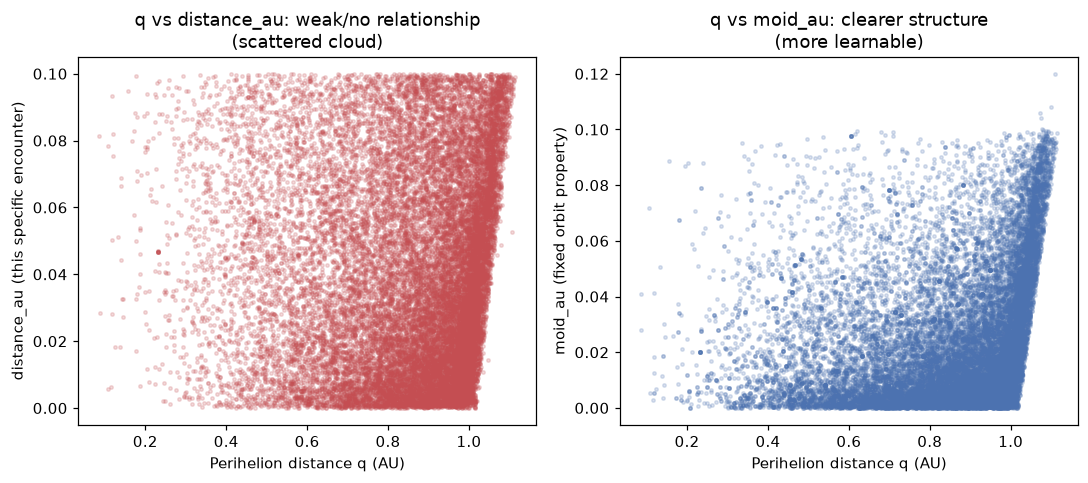

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].scatter(train["q"], train["distance_au"], s=5, alpha=0.2, color="#C44E52")
axes[0].set_xlabel("Perihelion distance q (AU)")
axes[0].set_ylabel("distance_au (this specific encounter)")
axes[0].set_title("q vs distance_au: weak/no relationship\n(scattered cloud)")

axes[1].scatter(train["q"], train["moid_au"], s=5, alpha=0.2, color="#4C72B0")
axes[1].set_xlabel("Perihelion distance q (AU)")
axes[1].set_ylabel("moid_au (fixed orbit property)")
axes[1].set_title("q vs moid_au: clearer structure\n(more learnable)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feateng_01_distance_vs_moid_targets.png")
plt.show()

In [7]:
required_cols = engineered_cols + shape_features + ["moid_au", "pha", "is_future", "velocity_km_s"]
missing = [c for c in required_cols if c not in df.columns]
print("Missing required columns:", missing if missing else "None -- ready for modeling.")

Missing required columns: None -- ready for modeling.
